# 📈 Support Vector Regression (SVR)

## 🎯 Objective

In this notebook, we will learn how Support Vector Regression (SVR) works, train it on the California Housing dataset, evaluate its performance, and visualize the predictions.

---

# 📖 Theory

## What is Support Vector Regression (SVR)?

Support Vector Regression (SVR) is the regression version of the Support Vector Machine (SVM).

Instead of predicting classes, SVR predicts continuous numerical values.

The goal of SVR is to find a function that fits the data while keeping most prediction errors within a margin called **epsilon (ε)**.

Unlike Linear Regression, SVR can model complex, non-linear relationships using kernel functions.

---

## How SVR Works

1. Scale the input features.
2. Choose a kernel (Linear, Polynomial, or RBF).
3. Find the optimal hyperplane/function.
4. Ignore small errors within ε.
5. Penalize larger errors.
6. Predict continuous values.

---

## Common Kernels

- Linear Kernel
- Polynomial Kernel
- RBF (Radial Basis Function) ⭐ Most Common
- Sigmoid Kernel

---

## Advantages

- Works well for non-linear data
- Effective on small and medium-sized datasets
- Robust to overfitting with proper tuning

---

## Disadvantages

- Slow on large datasets
- Requires feature scaling
- Sensitive to hyperparameters

---

## Real-World Applications

- House Price Prediction
- Stock Price Prediction
- Sales Forecasting
- Energy Consumption Prediction

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

data = fetch_california_housing()

X = data.data
y = data.target

In [2]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["Price"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [5]:
model = SVR(

    kernel="rbf",

    C=100,

    epsilon=0.1
)

In [6]:
model.fit(X_train, y_train)

SVR(C=100)

In [7]:
y_pred = model.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE:", rmse)

print("R² :", r2)

MAE : 0.37170411199324344
MSE : 0.32010260562074844
RMSE: 0.5657761090932953
R² : 0.7557231284766868


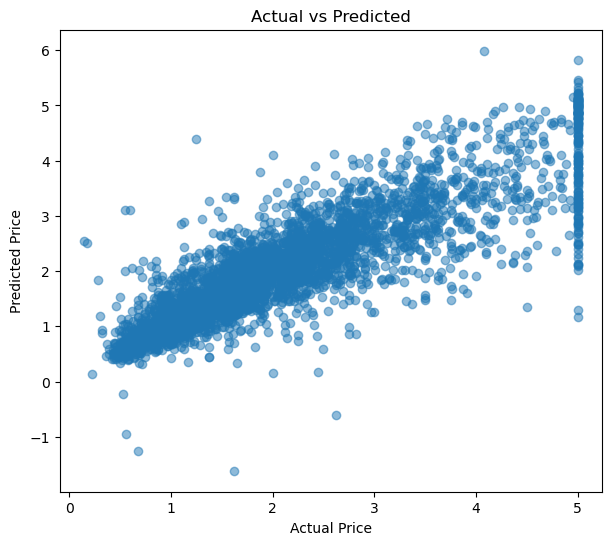

In [9]:
plt.figure(figsize=(7,6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [10]:
results = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred

})

results.head(10)

,Actual,Predicted
0,0.47700,0.478727
1,0.45800,1.373448
2,5.00001,4.811427
3,2.18600,2.452993
4,2.78000,2.957203
5,1.58700,1.559519
6,1.98200,2.528084
7,1.57500,1.644760
8,3.40000,2.439179
9,4.46600,4.728796


Model : Support Vector Regression

MAE  : Lower ✅

RMSE : Lower ✅

R²   : Higher ✅

SVR performs well on non-linear datasets.

Feature Scaling is mandatory.

RBF Kernel is the most commonly used kernel.